# Voxel island: fields become materials

Inspired by **Minecraft-Style World**, Flavio Adamo:
[catalog](https://github.com/magiccreator-ai/awesome-gpt-6-astra#minecraft-style-world) ·
[creator post](https://x.com/flavioAd/status/2095597137849446688).
[Explore our voxel world](https://jltobias.github.io/JupyterLite-Astra-demos/demos/?scene=voxel).

**Learn:** turn a continuous height field into a discrete volume, then assign materials.
**Predict:** what happens to memory if all three grid dimensions double?
This is an original procedural island, with no Minecraft code or assets. Coordinates are voxel units.


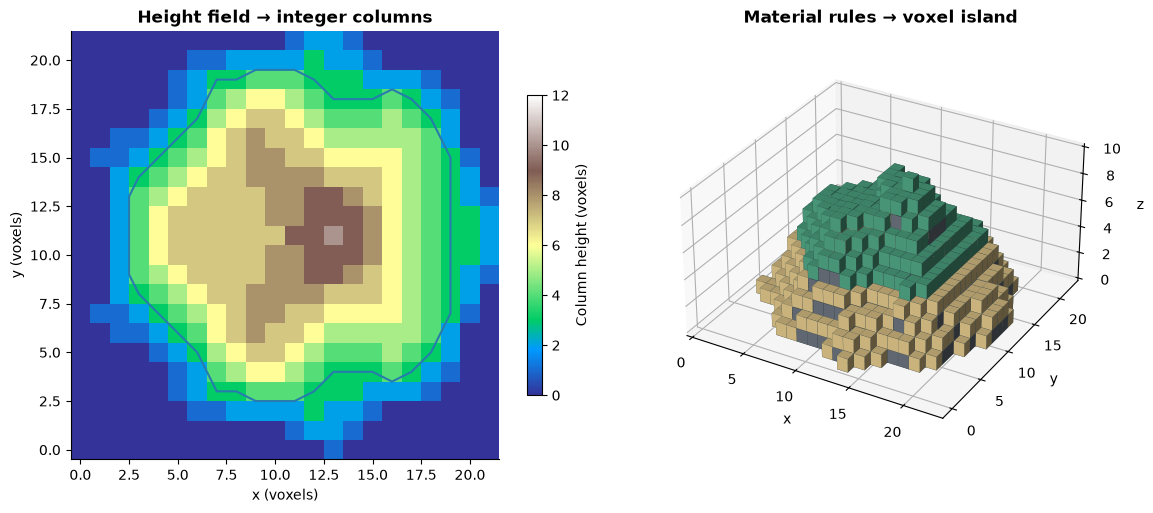

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astra_utils import style
style()
size = 22  # Keep below 35 for comfortable browser rendering.
x,y = np.meshgrid(np.arange(size),np.arange(size),indexing='ij')
u,v = (x-size/2)/(size/2),(y-size/2)/(size/2)
height = np.maximum(0,np.floor(9*(1-u*u-v*v)+1.4*np.sin(8*u)*np.cos(6*v))).astype(int)
z = np.arange(13)[None,None,:]
solid = z < height[:,:,None]
waterline = 3
water = (~solid) & (z < waterline)
colors = np.empty(solid.shape,dtype=object)
colors[:] = '#6d7580'
colors[(z == height[:,:,None]-1) & solid] = '#50a986'
colors[(z == height[:,:,None]-1) & (height[:,:,None] <= waterline+1) & solid] = '#e4c98c'
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(121)
im = ax.imshow(height.T,origin='lower',cmap='terrain',vmin=0,vmax=12)
ax.contour(height.T,levels=[waterline],colors='#277cad')
ax.set(title='Height field → integer columns',xlabel='x (voxels)',ylabel='y (voxels)')
fig.colorbar(im,ax=ax,label='Column height (voxels)',shrink=.7)
ax = fig.add_subplot(122,projection='3d')
ax.voxels(solid,facecolors=colors,edgecolor='#213d42',linewidth=.08)
ax.set(title='Material rules → voxel island',xlabel='x',ylabel='y',zlabel='z')
ax.set_box_aspect((1,1,.55))
fig.tight_layout()
plt.show()


**Visual bridge:** each colored map sample becomes a stack of occupied cells. Green marks high
surface cells; sand marks low shores; rock fills the interior. Water is a separate occupancy mask.
A dense volume stores even empty cells. Real renderers often draw only exposed faces or use chunks.


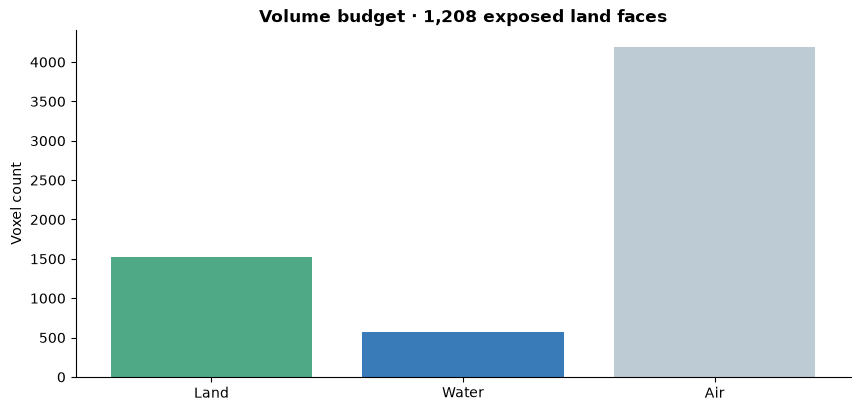

Dense grid: 6,292 cells; solid fraction: 24.3%


In [2]:
occupied = np.pad(solid,1)
exposed_faces = 0
for axis in range(3):
    exposed_faces += np.count_nonzero(np.diff(occupied.astype(int),axis=axis))
counts = [solid.sum(),water.sum(),solid.size-solid.sum()-water.sum()]
plt.bar(['Land','Water','Air'],counts,color=['#50a986','#397ab9','#bdcbd4'])
plt.ylabel('Voxel count')
plt.title(f'Volume budget · {exposed_faces:,} exposed land faces')
plt.show()
print(f'Dense grid: {solid.size:,} cells; solid fraction: {solid.mean():.1%}')
assert not np.any(solid & water)
assert np.array_equal(solid.sum(axis=2),height)


**Experiment:** change the waterline. Predict the material changes before rerunning both cells.
Then increase grid resolution while keeping the same physical island extent: you need to scale
the voxel size and vertical sampling too if you want the same world rather than a stretched one.

**Check:** doubling three dimensions requires eight times as many dense cells. A height map can
represent one top surface per column; caves and overhangs require richer geometry.
